In [22]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
!python --version

Python 3.11.8


In [3]:
import sys
import os

# Add project root, which is one level up the notebook folder, in the main dir
sys.path.append(os.path.abspath(".."))

# then bc we ran uv add --dev --editable, we can import the src package
import src.data_preperation as prep

In [4]:
import os
import pandas as pd

data_path = "../cache/UCI HAR Dataset/"

# 1. Load the feature names as you already did
features = pd.read_csv(os.path.join(data_path, 'features.txt'), 
                       sep=r'\s+', header=None, names=['ID', 'FeatureName'])

# 2. Load the Subject IDs
sub_train = pd.read_csv(os.path.join(data_path, 'train/subject_train.txt'), 
                        header=None, names=['SubjectID'])

sub_test = pd.read_csv(os.path.join(data_path, 'test/subject_test.txt'), 
                       header=None, names=['SubjectID'])

# 3. Load the Activity Labels (y)
y_train = pd.read_csv(os.path.join(data_path, 'train/y_train.txt'), 
                       header=None, names=['ActivityID'])

y_test = pd.read_csv(os.path.join(data_path, 'test/y_test.txt'), 
                      header=None, names=['ActivityID'])

# 4. Load your main features (X)
X_train = pd.read_csv(os.path.join(data_path, 'train/X_train.txt'), sep=r'\s+', header=None)
X_train.columns = features['FeatureName']

X_test = pd.read_csv(os.path.join(data_path, 'test/X_test.txt'), sep=r'\s+', header=None)
X_test.columns = features['FeatureName']

# 5. Insert SubjectID and ActivityID at the front of your DataFrames for easy tracking
X_train.insert(0, 'SubjectID', sub_train['SubjectID'])
X_train.insert(1, 'ActivityID', y_train['ActivityID'])

X_test.insert(0, 'SubjectID', sub_test['SubjectID'])
X_test.insert(1, 'ActivityID', y_test['ActivityID'])

/var/folders/j1/44pzm6b57_1_2205_k8pc_440000gp/T/ipykernel_53392/3585236273.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train.insert(0, 'SubjectID', sub_train['SubjectID'])
/var/folders/j1/44pzm6b57_1_2205_k8pc_440000gp/T/ipykernel_53392/3585236273.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train.insert(1, 'ActivityID', y_train['ActivityID'])
/var/folders/j1/44pzm6b57_1_2205_k8pc_440000gp/T/ipykernel_53392/3585236273.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of 

In [5]:
X_train

FeatureName,SubjectID,ActivityID,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,1,5,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,1,5,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,1,5,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,1,5,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,1,5,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347,30,2,0.299665,-0.057193,-0.181233,-0.195387,0.039905,0.077078,-0.282301,0.043616,...,-0.070157,-0.588433,-0.880324,-0.190437,0.829718,0.206972,-0.425619,-0.791883,0.238604,0.049819
7348,30,2,0.273853,-0.007749,-0.147468,-0.235309,0.004816,0.059280,-0.322552,-0.029456,...,0.165259,-0.390738,-0.680744,0.064907,0.875679,-0.879033,0.400219,-0.771840,0.252676,0.050053
7349,30,2,0.273387,-0.017011,-0.045022,-0.218218,-0.103822,0.274533,-0.304515,-0.098913,...,0.195034,0.025145,-0.304029,0.052806,-0.266724,0.864404,0.701169,-0.779133,0.249145,0.040811
7350,30,2,0.289654,-0.018843,-0.158281,-0.219139,-0.111412,0.268893,-0.310487,-0.068200,...,0.013865,0.063907,-0.344314,-0.101360,0.700740,0.936674,-0.589479,-0.785181,0.246432,0.025339


In [6]:
X_test

FeatureName,SubjectID,ActivityID,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,2,5,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,...,0.071645,-0.330370,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978
1,2,5,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,...,-0.401189,-0.121845,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898
2,2,5,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,...,0.062891,-0.190422,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346
3,2,5,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,...,0.116695,-0.344418,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108
4,2,5,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,...,-0.121711,-0.534685,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2942,24,2,0.310155,-0.053391,-0.099109,-0.287866,-0.140589,-0.215088,-0.356083,-0.148775,...,0.074472,-0.376278,-0.750809,-0.337422,0.346295,0.884904,-0.698885,-0.651732,0.274627,0.184784
2943,24,2,0.363385,-0.039214,-0.105915,-0.305388,0.028148,-0.196373,-0.373540,-0.030036,...,0.101859,-0.320418,-0.700274,-0.736701,-0.372889,-0.657421,0.322549,-0.655181,0.273578,0.182412
2944,24,2,0.349966,0.030077,-0.115788,-0.329638,-0.042143,-0.250181,-0.388017,-0.133257,...,-0.066249,-0.118854,-0.467179,-0.181560,0.088574,0.696663,0.363139,-0.655357,0.274479,0.181184
2945,24,2,0.237594,0.018467,-0.096499,-0.323114,-0.229775,-0.207574,-0.392380,-0.279610,...,-0.046467,-0.205445,-0.617737,0.444558,-0.819188,0.929294,-0.008398,-0.659719,0.264782,0.187563


In [13]:
X_train.shape[1]

563

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Clean up column tracking (assuming SubjectID and ActivityID are in X_train now)
# We will drop metadata columns for the mathematical PCA calculation
feature_cols = [c for c in X_train.columns if c not in ['SubjectID', 'ActivityID', 'FeatureName']]

# 2. Standardize the 561 features (PCA is highly sensitive to variances)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train[feature_cols])

# 3. Apply PCA
pca = PCA(n_components=(X_train.shape[1] - 3))  # Keep all components for now
X_pca = pca.fit_transform(X_scaled)

# 4. Map back to a plotting dataframe
pca_df = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['SubjectID'] = X_train['SubjectID'].values
pca_df['ActivityID'] = X_train['ActivityID'].values

# Map numeric labels to meaningful text for the second check
activity_names = {1: 'Walk', 2: 'Upstairs', 3: 'Downstairs', 4: 'Sit', 5: 'Stand', 6: 'Lay'}
pca_df['Activity'] = pca_df['ActivityID'].map(activity_names)

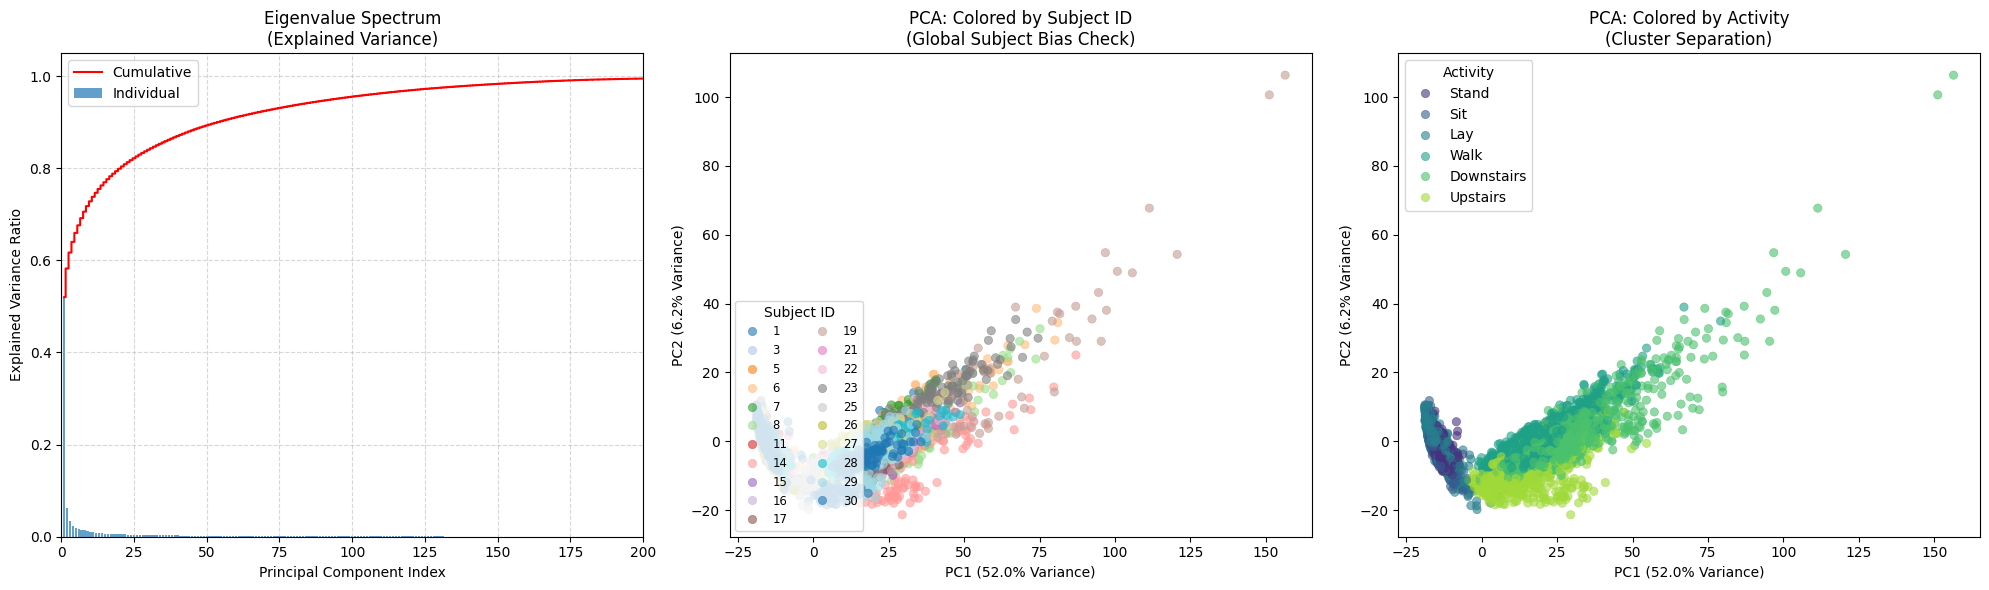

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a 3-panel figure layout (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# -----------------------------------------------------------------------------
# Panel 1: Eigenvalue Spectrum (Scree Plot)
# -----------------------------------------------------------------------------
# Quantify the variance explained by each principal component
exp_var = pca.explained_variance_ratio_

axes[0].bar(range(1, len(exp_var) + 1), exp_var, alpha=0.7, align='center', label='Individual')
axes[0].step(range(1, len(exp_var) + 1), exp_var.cumsum(), where='mid', label='Cumulative', color='red')
axes[0].set_title('Eigenvalue Spectrum\n(Explained Variance)')
axes[0].set_xlabel('Principal Component Index')
axes[0].set_ylabel('Explained Variance Ratio')
# Limit x-axis to show the most important components (adjust as needed)
axes[0].set_xlim(0, 200)
axes[0].legend(loc='best')
axes[0].grid(True, linestyle='--', alpha=0.5)

# -----------------------------------------------------------------------------
# Panel 2: PCA Colored by Subject ID
# -----------------------------------------------------------------------------
sns.scatterplot(
    data=pca_df, 
    x='PC1', 
    y='PC2', 
    hue='SubjectID', 
    palette='tab20', 
    alpha=0.6,
    edgecolor=None,
    ax=axes[1] # Directs plot to the second panel
)
axes[1].set_title('PCA: Colored by Subject ID\n(Global Subject Bias Check)')
axes[1].set_xlabel(f'PC1 ({exp_var[0]:.1%} Variance)')
axes[1].set_ylabel(f'PC2 ({exp_var[1]:.1%} Variance)')
# Keep the subject legend tight since there are many subjects
axes[1].legend(title='Subject ID', loc='lower left', ncol=2, fontsize='small')

# -----------------------------------------------------------------------------
# Panel 3: PCA Colored by Activity
# -----------------------------------------------------------------------------
sns.scatterplot(
    data=pca_df, 
    x='PC1', 
    y='PC2', 
    hue='Activity', # Make sure 'Activity' matches the column name in pca_df
    palette='viridis', 
    alpha=0.6,
    edgecolor=None,
    ax=axes[2] # Directs plot to the third panel
)
axes[2].set_title('PCA: Colored by Activity\n(Cluster Separation)')
axes[2].set_xlabel(f'PC1 ({exp_var[0]:.1%} Variance)')
axes[2].set_ylabel(f'PC2 ({exp_var[1]:.1%} Variance)')
axes[2].legend(title='Activity', loc='best')

# Final formatting adjustments
plt.tight_layout()
plt.show()

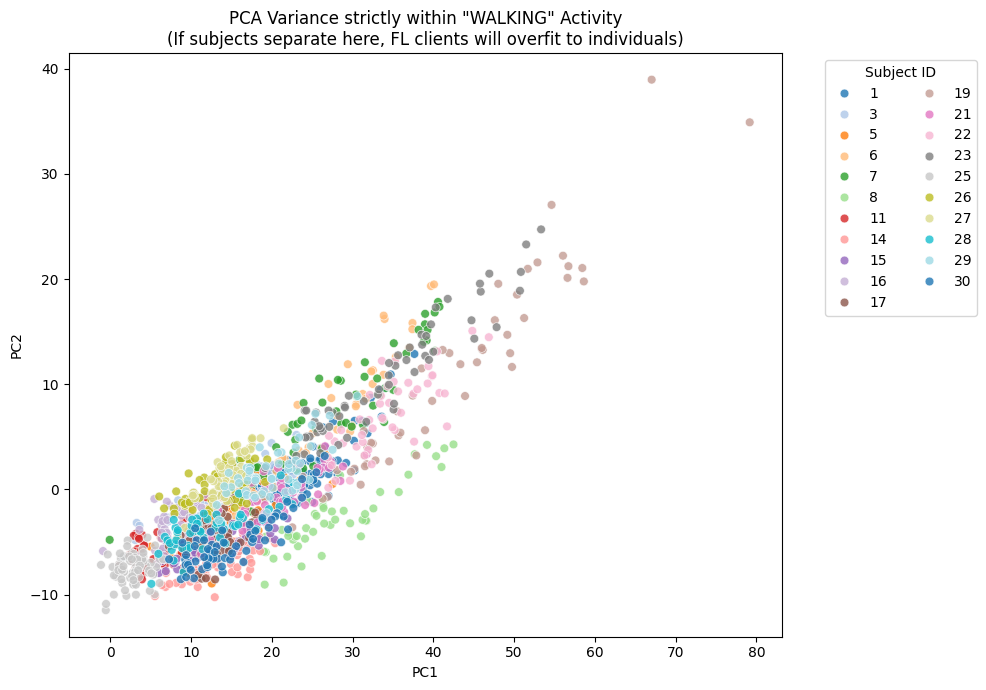

In [9]:
# Filter down to a single dynamic activity (e.g., WALKING = 1)
walking_df = pca_df[pca_df['ActivityID'] == 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=walking_df, 
    x='PC1', 
    y='PC2', 
    hue='SubjectID', 
    palette='tab20', 
    alpha=0.8,
    s=40
)
plt.title('PCA Variance strictly within "WALKING" Activity\n(If subjects separate here, FL clients will overfit to individuals)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Subject ID', ncol=2)
plt.tight_layout()
plt.show()

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Clean up column tracking (assuming SubjectID and ActivityID are in X_train now)
# We will drop metadata columns for the mathematical PCA calculation
feature_cols = [c for c in X_train.columns if c not in ['SubjectID', 'ActivityID']]

# 2. Standardize the 561 features (PCA is highly sensitive to variances)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train[feature_cols])

# 3. Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Map back to a plotting dataframe
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['SubjectID'] = X_train['SubjectID'].values
pca_df['ActivityID'] = X_train['ActivityID'].values

# Map numeric labels to meaningful text for the second check
activity_names = {1: 'Walk', 2: 'Upstairs', 3: 'Downstairs', 4: 'Sit', 5: 'Stand', 6: 'Lay'}
pca_df['Activity'] = pca_df['ActivityID'].map(activity_names)

/home/penguin/Projekte/Activity-Classification/FML-Activity-Classification/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/penguin/Projekte/Activity-Classification/FML-Activity-Classification/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


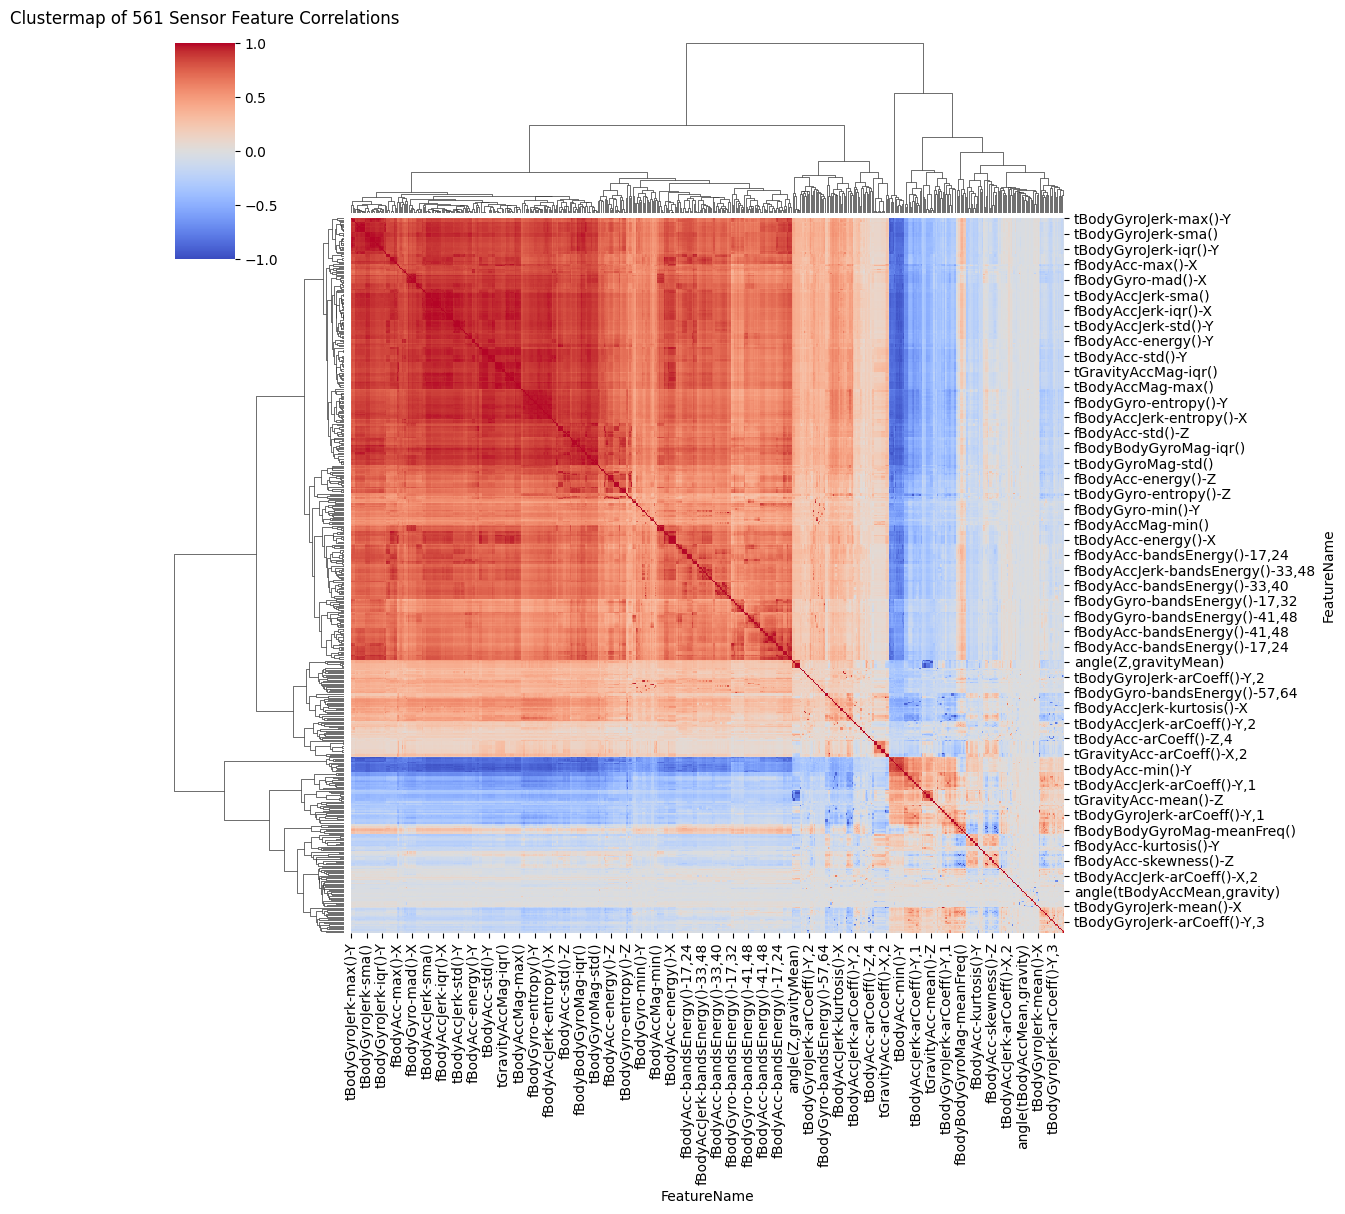

In [17]:
# default uses pearson, can only detect linear relationships, but is more straightforward
corr_matrix = X_train.corr()

g = sns.clustermap(corr_matrix, 
                   annot=False,       # set to false when using all 561 features to avoid clutter
                   cmap='coolwarm',
                   vmin=-1, vmax=1,  #Ensure the scale is anchored at -1 and 1
                   figsize=(12, 12))

# 3. Adjust plot labels
plt.title("Clustermap of 561 Sensor Feature Correlations", y=1.05)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90)
plt.show()

In [18]:
# Die Labels (Antworten) laden
y_train = pd.read_csv(os.path.join(data_path, 'train/y_train.txt'), 
                      sep=r'\s+', header=None, names=['ActivityID'])

# Schauen, wie die Verteilung aussieht
print(y_train['ActivityID'].value_counts())

ActivityID
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64


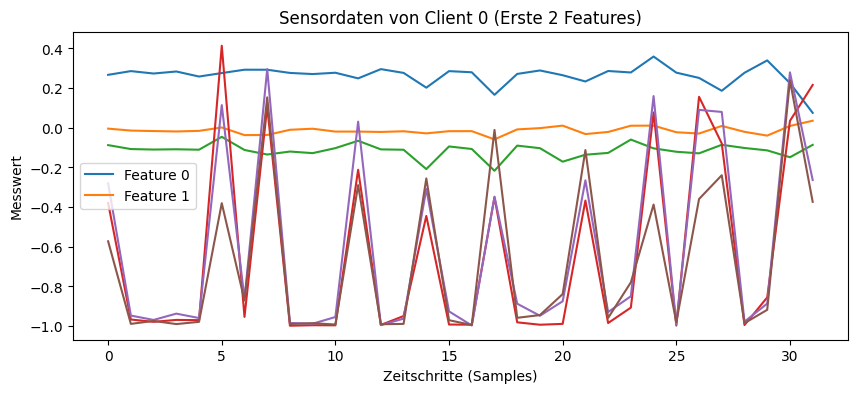

In [20]:

from src.data_loader import get_client_loader


loader = get_client_loader(client_id=0, batch_size=32)

#holt sich batch und nimmt erstes paket. 
X_batch, y_batch = next(iter(loader))

# plotten
plt.figure(figsize=(10, 4))
plt.plot(X_batch[:100, 0:6]) 
plt.title("Sensordaten von Client 0 (Erste 2 Features)")
plt.xlabel("Zeitschritte (Samples)")
plt.ylabel("Messwert")
plt.legend(["Feature 0", "Feature 1"])
plt.show()